In [1]:
import importlib
from tqdm.auto import tqdm
import os
import pickle

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np 
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from model import GenderChunkedClassifier
from gender_dataset import MultiSpeciesGenderDataChunkedDataset, worker_init_fn, collate_fn

/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
tokenizer = AutoTokenizer.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t')
model = AutoModel.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', trust_remote_code=True)
model_module = importlib.import_module(model.__class__.__module__)
cls = getattr(model_module, 'BertModel')
model = cls.from_pretrained('AIRI-Institute/gena-lm-bert-base-t2t', add_pooling_layer=False)

/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/venv/lib/python3.12/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [3]:
gender_model = GenderChunkedClassifier(model)

In [4]:
from safetensors.torch import load_model
load_model(gender_model,
           
           '/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/runs/human_and_mouse_fixed_16x3072_bs_128_lr_1e-05_chrY_with_SNPs/run_1/checkpoint-94500/model.safetensors',
           )

# load_model(gender_model,
           
           
#            '/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/runs/human_and_mouse_16x3072_bs_128_lr_1e-05_chrY_with_SNPs/run_1/checkpoint-14750/model.safetensors',
#            )


(set(), [])

In [5]:
n_chunks = 16
chunk_size = 3072
seed = 142
bs = 64
chrX_ratio = 0.5
chrY_ratio = None
split_name='valid'

In [ ]:
valid_dataset = MultiSpeciesGenderDataChunkedDataset(split_name=split_name, n_chunks=n_chunks,
                                        chunk_size=chunk_size,
                                        force_sampling_from_y=False,
                                        chrY_ratio=chrY_ratio,
                                        chrX_ratio=chrX_ratio,
                                        seed=seed+1)


def preprocess_collate_fn(samples):
    batch = collate_fn(samples)

    batch['chunks'] = np.array(batch['chunks'])
    shape = batch['chunks'].shape
    batch['chunks'] = list(batch['chunks'].flatten())

    tokenized_batch = tokenizer(batch['chunks'], padding='longest', max_length=512,
                                truncation=True, return_tensors='pt')

    for k in tokenized_batch:
        tokenized_batch[k] = tokenized_batch[k].reshape(*shape, -1)

    batch['labels'] = torch.Tensor(batch['labels'])

    return {
        'input_ids': tokenized_batch['input_ids'],
        'attention_mask': tokenized_batch['attention_mask'],
        'labels': batch['labels'],
        'sample_ids': batch['sample_id'],
        'has_y_chr_sampled': batch['has_y_chr_sampled'],
        'has_x_chr_sampled': batch['has_x_chr_sampled'],
        'sampled_chromosomes': batch['sampled_chromosomes']
        }

valid_dataloader = DataLoader(valid_dataset, batch_size=bs, collate_fn=preprocess_collate_fn,
                          num_workers=2, pin_memory=True,
                          worker_init_fn=worker_init_fn)

In [7]:
# import h5py
# data = h5py.File("/home/jovyan/data/downstream_tasks/gender_classification/mouse_gender_data/test.h5",  'r')
# list(data.keys())

In [8]:
# for sample_id in data.keys():
#     assert any("chrX" in chr_name for chr_name in data[sample_id].keys())

## no chrY upsampling

In [9]:
gender_model = gender_model.cuda()

In [10]:
dataloader = valid_dataloader

N = 100000 // bs

labels = []
probs = []
sample_ids_list = []
contain_y_list = []
sampled_chromosomes_list = []

for b in tqdm(dataloader, total=N):

    # assert all(('chrX' not in chr) and ('chrY' not in chr) for chr in b['sampled_chromosomes'])
    # assert all('chrX' not in chr for chr in b['sampled_chromosomes'])
    # print(b['sampled_chromosomes'])

    for k in b:
        # put numerical features on gpu
        if k not in ['sample_ids', 'has_y_chr_sampled', 'sampled_chromosomes']:
            b[k] = b[k].cuda()


    with autocast(dtype=torch.bfloat16):
        with torch.no_grad():
            outputs = gender_model(b['input_ids'], b['attention_mask'])
            labels += list(b['labels'].cpu().numpy())
            probs += list(outputs['predictions'].float().cpu().numpy())
            sample_ids_list += b['sample_ids']
            sampled_chromosomes_list += b['sampled_chromosomes']
    N -= 1
    if N <= 0:
        break

  0%|          | 0/1562 [00:00<?, ?it/s]/home/jovyan/chepurova/dnalm/downstream_tasks/gender_classification/venv/lib/python3.12/site-packages/transformers/modeling_utils.py:1126: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(
100%|█████████▉| 1561/1562 [46:51<00:01,  1.80s/it]


In [11]:
labels = np.array(labels)
probs = np.array(probs)

sample_ids_labels = {sample_id: label for sample_id, label in zip(sample_ids_list, labels)}

sample_ids_sampled_chromosomes = {}

sample_ids_probs = {}

# aggregating probabilities for each sample 
for i, chrs in zip(sample_ids_list, sampled_chromosomes_list):
    if i in sample_ids_sampled_chromosomes:
        sample_ids_sampled_chromosomes[i] += chrs
    else:
        sample_ids_sampled_chromosomes[i] = chrs

# aggregating probabilities for each sample 
for i, p in zip(sample_ids_list, probs):
    if i in sample_ids_probs:
        sample_ids_probs[i] += [p]
    else:
        sample_ids_probs[i] = [p]

# converting prob arrays to numpy
for k in sample_ids_probs:
    sample_ids_probs[k] = np.array(sample_ids_probs[k])

for k in sample_ids_probs:
    probs = sample_ids_probs[k]
    print(f'{k}: [{sample_ids_labels[k]}] {(probs>0.5).sum() / len(probs):.2f}')

BALB_cJ: [1.0] 0.82
HG04018: [1.0] 0.23
NA12707: [0.0] 0.23
HG01936: [1.0] 0.24
HG00405: [1.0] 0.22
C57BL_10J: [0.0] 0.81
HG02947: [0.0] 0.23
HG02554: [0.0] 0.23
C57L_J: [0.0] 0.81
DBA_1J: [0.0] 0.82
HG01067: [1.0] 0.23
NZW_LacJ: [0.0] 0.83
129S5SvEvBrd: [1.0] 0.82
DBA_2J: [1.0] 0.82
HG03807: [1.0] 0.23
NA20528: [0.0] 0.23
LEWES_EiJ: [1.0] 0.82
NZO_HlLtJ: [1.0] 0.82
HG02489: [0.0] 0.24
SPRET_EiJ: [1.0] 0.81


In [12]:
for k in sample_ids_probs:
    probs = sample_ids_probs[k]
    print(f'{k:20s}: [{sample_ids_labels[k]}] {(probs>5e-1).sum()}/{len(probs)} = {(probs>5e-1).sum() / len(probs):.3f}')

BALB_cJ             : [1.0] 4090/5010 = 0.816
HG04018             : [1.0] 1154/5074 = 0.227
NA12707             : [0.0] 1133/4902 = 0.231
HG01936             : [1.0] 1228/5092 = 0.241
HG00405             : [1.0] 1118/5028 = 0.222
C57BL_10J           : [0.0] 4002/4922 = 0.813
HG02947             : [0.0] 1130/4832 = 0.234
HG02554             : [0.0] 1142/4936 = 0.231
C57L_J              : [0.0] 3939/4840 = 0.814
DBA_1J              : [0.0] 4102/4996 = 0.821
HG01067             : [1.0] 1204/5166 = 0.233
NZW_LacJ            : [0.0] 4230/5112 = 0.827
129S5SvEvBrd        : [1.0] 3992/4844 = 0.824
DBA_2J              : [1.0] 4210/5160 = 0.816
HG03807             : [1.0] 1137/5040 = 0.226
NA20528             : [0.0] 1182/5036 = 0.235
LEWES_EiJ           : [1.0] 3908/4768 = 0.820
NZO_HlLtJ           : [1.0] 4078/5002 = 0.815
HG02489             : [0.0] 1193/5064 = 0.236
SPRET_EiJ           : [1.0] 4177/5144 = 0.812


In [13]:
f'{split_name}_without_Y_100k_human_mouse_Ysnps{seed}.pckl'

'valid_100k_human_mouse_Ysnps142.pckl'

In [ ]:
# saving 

pickle.dump({'sample_ids_probs': sample_ids_probs, 'sample_ids_labels': sample_ids_labels, 'sample_ids_sampled_chromosomes': sample_ids_sampled_chromosomes},
            open(f'{split_name}_without_Y_100k_human_mouse_Ysnps{seed}.pckl', 'wb'))

d = pickle.load(open(f'{split_name}_without_Y_100k_human_mouse_Ysnps{seed}.pckl', 'rb'))

sample_ids_probs = d['sample_ids_probs']
sample_ids_labels = d['sample_ids_labels']
sample_ids_sampled_chromosomes = d['sample_ids_sampled_chromosomes']


sample_ids_sorted = [el[0] for el in sorted(sample_ids_labels.items(), key=lambda x: x[1])]

thr = 0.5039062
# thr = 0.300
for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    y_in_chr = any(['chrY' in chr for chr in sample_ids_sampled_chromosomes[k]])
    x_in_chr = any(['chrX' in chr for chr in sample_ids_sampled_chromosomes[k]])
    print(f"{k}: [{sample_ids_labels[k]}] {(probs>thr).sum()}/{len(probs)} = {(probs>thr).sum() / len(probs):.3f}")

NA12707: [0.0] 1060/4990 = 0.212
C57BL_10J: [0.0] 2544/4984 = 0.510
HG02947: [0.0] 1028/4966 = 0.207
HG02489: [0.0] 1075/5096 = 0.211
DBA_1J: [0.0] 2563/5010 = 0.512
C57L_J: [0.0] 2549/4988 = 0.511
NZW_LacJ: [0.0] 2530/4988 = 0.507
NA20528: [0.0] 1023/5062 = 0.202
HG02554: [0.0] 1057/5038 = 0.210
BALB_cJ: [1.0] 4093/5012 = 0.817
HG04018: [1.0] 1124/4832 = 0.233
HG01936: [1.0] 1192/5160 = 0.231
HG00405: [1.0] 1099/4802 = 0.229
HG01067: [1.0] 1146/4908 = 0.233
LEWES_EiJ: [1.0] 4139/5066 = 0.817
129S5SvEvBrd: [1.0] 4061/4970 = 0.817
HG03807: [1.0] 1133/4844 = 0.234
SPRET_EiJ: [1.0] 4097/5048 = 0.812
DBA_2J: [1.0] 4165/5162 = 0.807
NZO_HlLtJ: [1.0] 4119/5042 = 0.817


In [7]:
f'{split_name}_100k_human_mouse_Ysnps{seed}.pckl'

'valid_100k_human_mouse_Ysnps142.pckl'

In [10]:
# combine all generated data

dumps = [
        'valid_100k_human_mouse_Ysnps142.pckl', \
         ]

sample_ids_probs = None
sample_ids_labels = None
sample_ids_sampled_chromosomes = None

for dump in dumps:

    d = pickle.load(open(dump, 'rb'))
    if sample_ids_labels is None:
        sample_ids_labels = d['sample_ids_labels']

    if sample_ids_probs is None:
        sample_ids_probs = d['sample_ids_probs']

    if sample_ids_sampled_chromosomes is None:
        sample_ids_sampled_chromosomes = d['sample_ids_sampled_chromosomes']
          
    else:
        sample_ids_labels.update(d['sample_ids_labels'])

        for k in d['sample_ids_probs']:
            if k in sample_ids_probs:
                sample_ids_probs[k] = np.concatenate([sample_ids_probs[k], d['sample_ids_probs'][k]])
            else:
                sample_ids_probs[k] = d['sample_ids_probs'][k]
        
        for k in d['sample_ids_sampled_chromosomes']:
            if k in sample_ids_sampled_chromosomes:
                sample_ids_sampled_chromosomes[k] = np.concatenate([sample_ids_sampled_chromosomes[k], d['sample_ids_sampled_chromosomes'][k]])
            else:
                sample_ids_sampled_chromosomes[k] = d['sample_ids_sampled_chromosomes'][k]

accuracy: 0.550, thr: 0.371
NA12707        : [0.0] 1060/4990 = 0.212 pred: [1]
C57BL_10J      : [0.0] 2544/4984 = 0.510 pred: [0]
HG02947        : [0.0] 1028/4966 = 0.207 pred: [1]
HG02489        : [0.0] 1075/5096 = 0.211 pred: [1]
DBA_1J         : [0.0] 2563/5010 = 0.512 pred: [0]
C57L_J         : [0.0] 2549/4988 = 0.511 pred: [0]
NZW_LacJ       : [0.0] 2530/4988 = 0.507 pred: [0]
NA20528        : [0.0] 1023/5062 = 0.202 pred: [1]
HG02554        : [0.0] 1057/5038 = 0.210 pred: [1]
BALB_cJ        : [1.0] 4093/5012 = 0.817 pred: [0]
HG04018        : [1.0] 1124/4832 = 0.233 pred: [1]
HG01936        : [1.0] 1192/5160 = 0.231 pred: [1]
HG00405        : [1.0] 1099/4802 = 0.229 pred: [1]
HG01067        : [1.0] 1146/4908 = 0.233 pred: [1]
LEWES_EiJ      : [1.0] 4139/5066 = 0.817 pred: [0]
129S5SvEvBrd   : [1.0] 4061/4970 = 0.817 pred: [0]
HG03807        : [1.0] 1133/4844 = 0.234 pred: [1]
SPRET_EiJ      : [1.0] 4097/5048 = 0.812 pred: [0]
DBA_2J         : [1.0] 4165/5162 = 0.807 pred: [0]
NZO

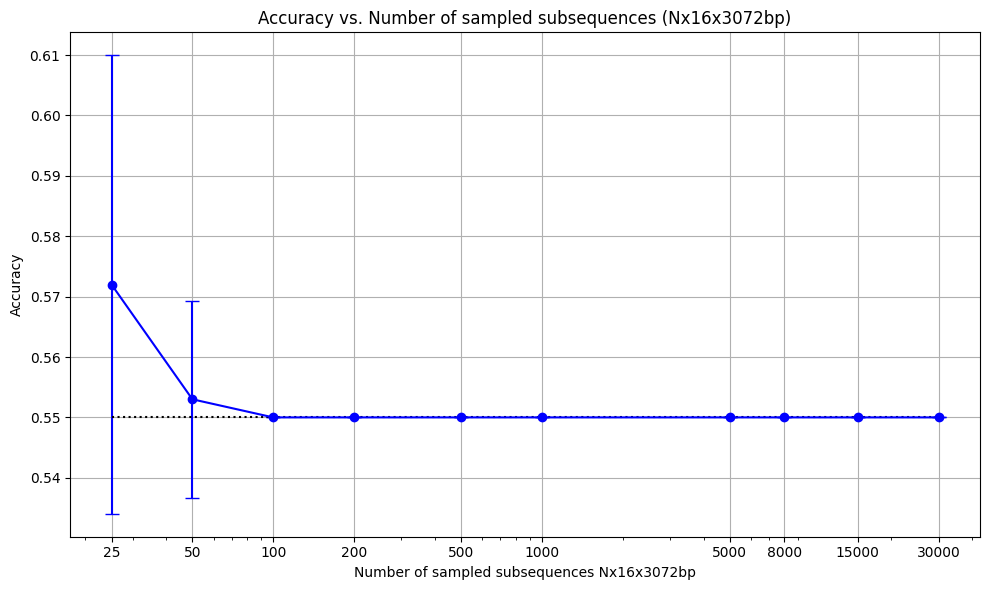

In [11]:
sample_ids_sorted = [el[0] for el in sorted(sample_ids_labels.items(), key=lambda x: x[1])]

thr = 0.5

ratios = []
for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    ratios += [(probs>thr).sum() / len(probs)]

ratios = np.array(ratios)

acc = 0

# threshold - median ratio of probababilites > 0.5 for each sample

for k, r in zip(sample_ids_sorted, ratios):
    acc += int(int(r > np.median(ratios)) == sample_ids_labels[k])

acc = acc / len(sample_ids_sorted)
print(f'accuracy: {acc:0.3f}, thr: {np.median(ratios):0.3f}')


for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    r = (probs>thr).sum()/len(probs)
    print(f"{k:15s}: [{sample_ids_labels[k]}] {(probs>thr).sum()}/{len(probs)} = {r:.3f} pred: [{int(r<np.median(ratios))}]")

Ns = [25, 50, 100, 200, 500, 1000, 5000, 8000, 15000, 30000]
# thr = 0.3
accs = []
stds = []


for N in Ns:
    N_accs = []
    for i in range(200):
        ratios = []
        for k in sample_ids_sorted:
            probs = sample_ids_probs[k]
            probs = np.random.choice(probs[:,0],size=min(N, len(probs)))
            ratios += [(probs>thr).sum() / len(probs)]
            print(f"{k}: [{sample_ids_labels[k]}] {(probs>thr).sum()}/{len(probs)} = {(probs>thr).sum() / len(probs):.3f}")

        ratios = np.array(ratios)

        acc = 0
        for k, r in zip(sample_ids_sorted, ratios):
            acc += int(int(r > np.median(ratios)) == sample_ids_labels[k])
        acc = acc / len(sample_ids_sorted)
        N_accs += [acc]
    accs += [np.mean(N_accs)]
    stds.append(np.std(N_accs))

# Creating the plot
plt.figure(figsize=(10, 6))
plt.errorbar(Ns, accs, yerr=stds, marker='o', linestyle='-', color='b', capsize=5)
plt.hlines(np.mean(list(sample_ids_labels.values())), xmin=min(Ns), xmax=max(Ns), color='black', linestyle='dotted')
plt.title(f'Accuracy vs. Number of sampled subsequences (Nx16x3072bp)')
plt.xlabel('Number of sampled subsequences Nx16x3072bp')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xscale('log')  # Optional: Use logarithmic scale for better visualization if needed
plt.xticks(Ns, labels=[str(n) for n in Ns])  # Ensure that all N values are labeled
plt.tight_layout()
plt.show()

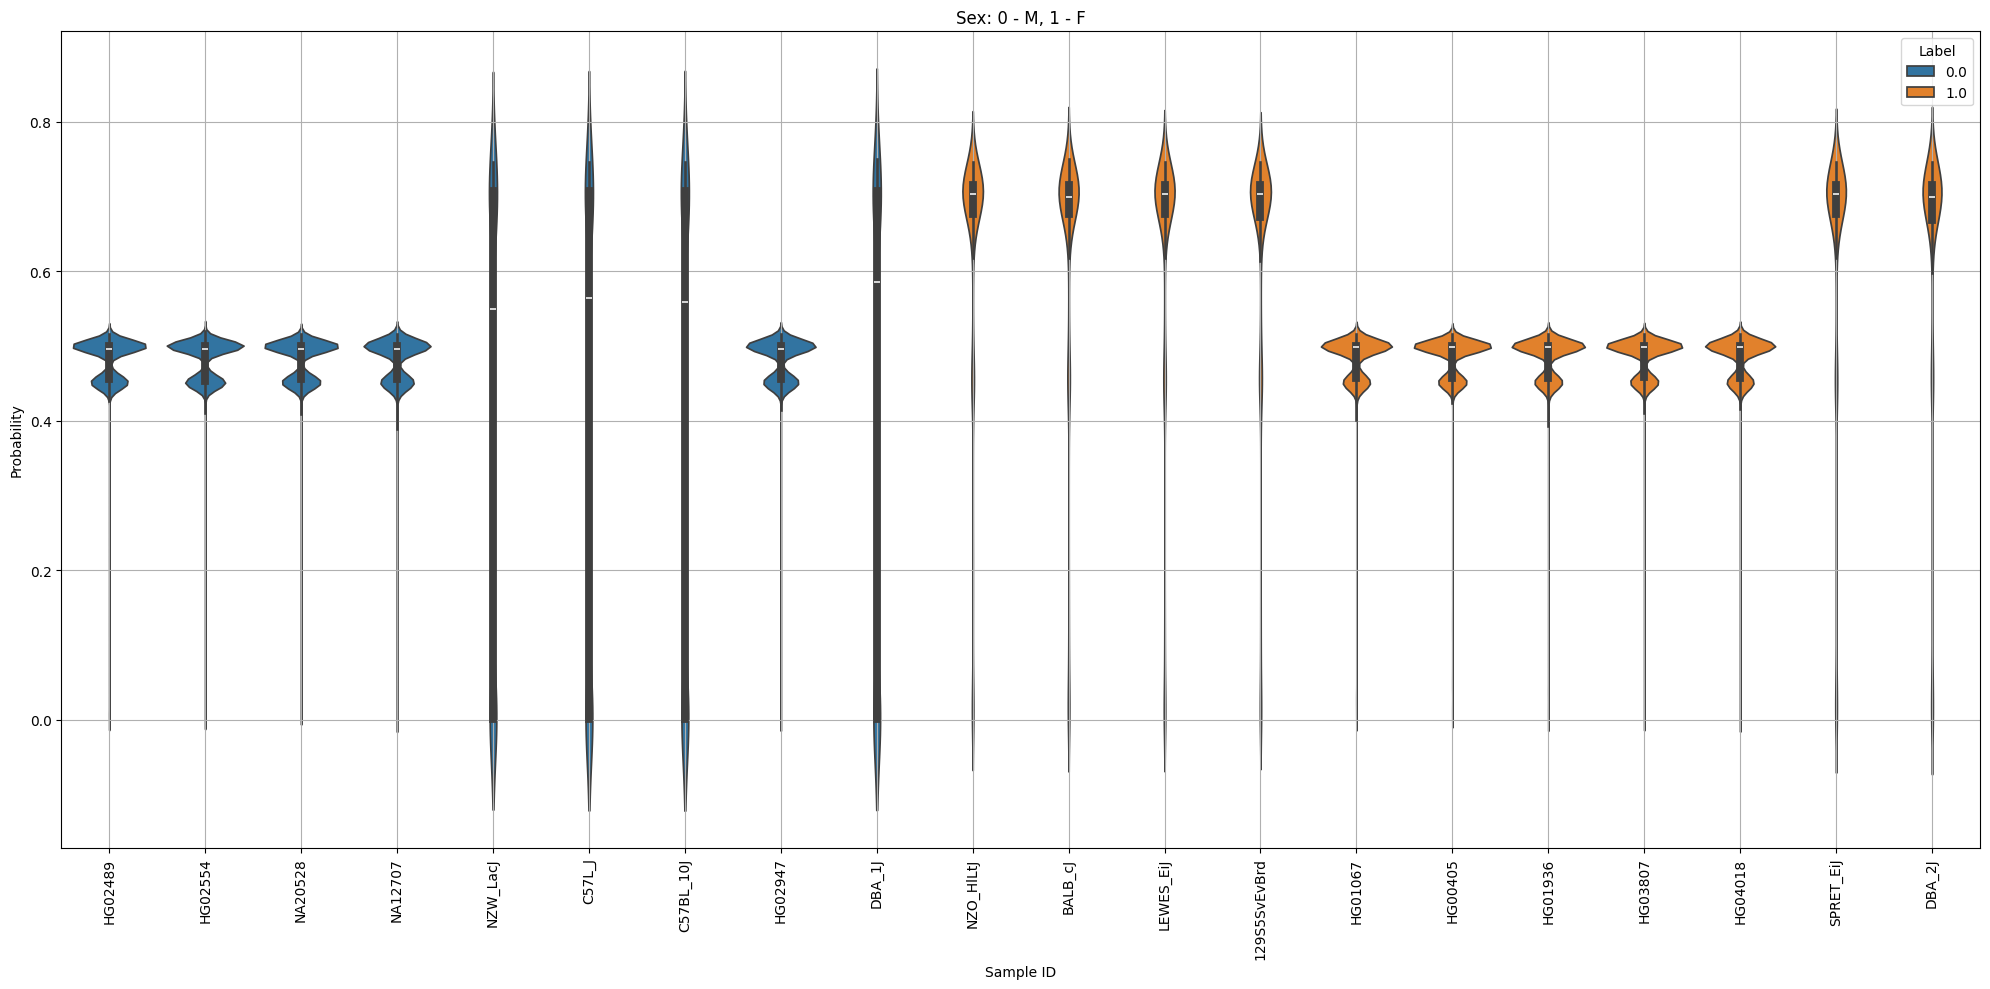

In [12]:
# Prepare DataFrame for plotting
data_list = []
for sample_id, probs in sample_ids_probs.items():
    for prob in probs:
        data_list.append({
            'Sample ID': sample_id,  # Convert to string for consistent key usage
            'Probability': prob[0],
            'Label': sample_ids_labels[sample_id]
        })

df = pd.DataFrame(data_list)

# Sort data by label for plotting
label_order = sorted(df['Label'].unique())
sample_order = df.sort_values(by='Label')['Sample ID'].unique()

# Plotting
plt.figure(figsize=(20, 10))  # Adjusted size for better visibility
ax = sns.violinplot(x='Sample ID', y='Probability', hue='Label', data=df, inner='box',
                    order=sample_order, hue_order=label_order)
# sns.stripplot(x='Sample ID', y='Probability', data=df, color='black', size=1, jitter=True, order=sample_order)
plt.title('Sex: 0 - M, 1 - F')
plt.xticks(rotation=90)
plt.xlabel('Sample ID')
plt.ylabel('Probability')
plt.legend(title='Label')
plt.tight_layout()
plt.grid()
plt.show()

In [13]:
labels_human_test = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/human_gender_data/test.csv")
labels_mouse_test = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/mouse_gender_data/test.csv")

labels_human_valid = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/human_gender_data/valid.csv")
labels_mouse_valid = pd.read_csv("/home/jovyan/data/downstream_tasks/gender_classification/mouse_gender_data/valid.csv")

In [14]:
labels_map = {1: 0, 2: 1, 'M': 0, 'F': 1}
labels_mouse_valid['gender'] = labels_mouse_valid['gender'].apply(lambda x: labels_map[x])
labels_mouse_test['gender'] = labels_mouse_test['gender'].apply(lambda x: labels_map[x])

labels_human_test['sex'] = labels_human_test['sex'].apply(lambda x: labels_map[x])
labels_human_valid['sex'] = labels_human_valid['sex'].apply(lambda x: labels_map[x])

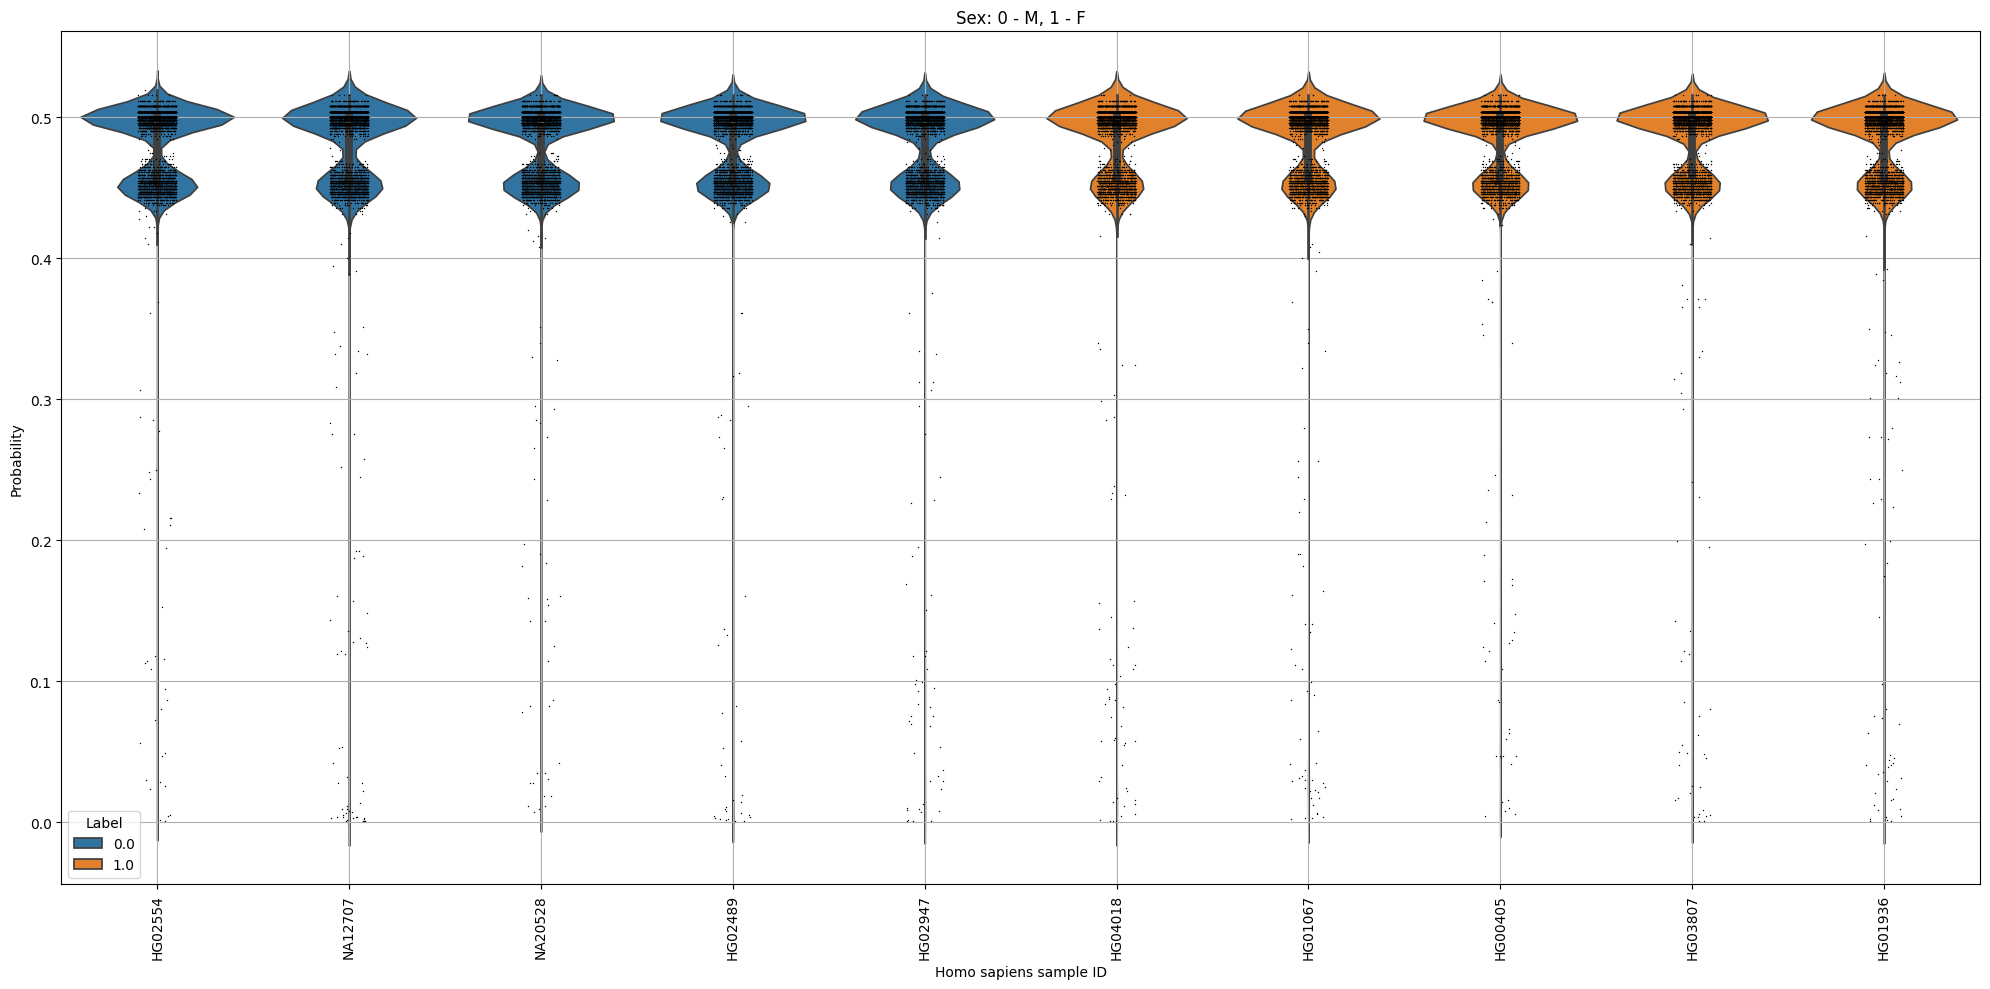

In [24]:
# Prepare DataFrame for plotting
data_list = []
for sample_id, probs in sample_ids_probs.items():
    if sample_id in list(labels_human_valid['sample']) or sample_id in list(labels_human_test['sample']):
        for prob in probs:
            data_list.append({
                'Sample ID': sample_id,  # Convert to string for consistent key usage
                'Probability': prob[0],
                'Label': sample_ids_labels[sample_id]
            })

df = pd.DataFrame(data_list)

# Sort data by label for plotting
label_order = sorted(df['Label'].unique())
sample_order = df.sort_values(by='Label')['Sample ID'].unique()

# Plotting
plt.figure(figsize=(20, 10))  # Adjusted size for better visibility
ax = sns.violinplot(x='Sample ID', y='Probability', hue='Label', data=df, inner='box',
                    order=sample_order, hue_order=label_order)
sns.stripplot(x='Sample ID', y='Probability', data=df, color='black', size=1, jitter=True, order=sample_order)
plt.title('Sex: 0 - M, 1 - F')
plt.xticks(rotation=90)
plt.xlabel('Homo sapiens sample ID')
plt.ylabel('Probability')
plt.legend(title='Label')
plt.tight_layout()
plt.grid()
plt.show()

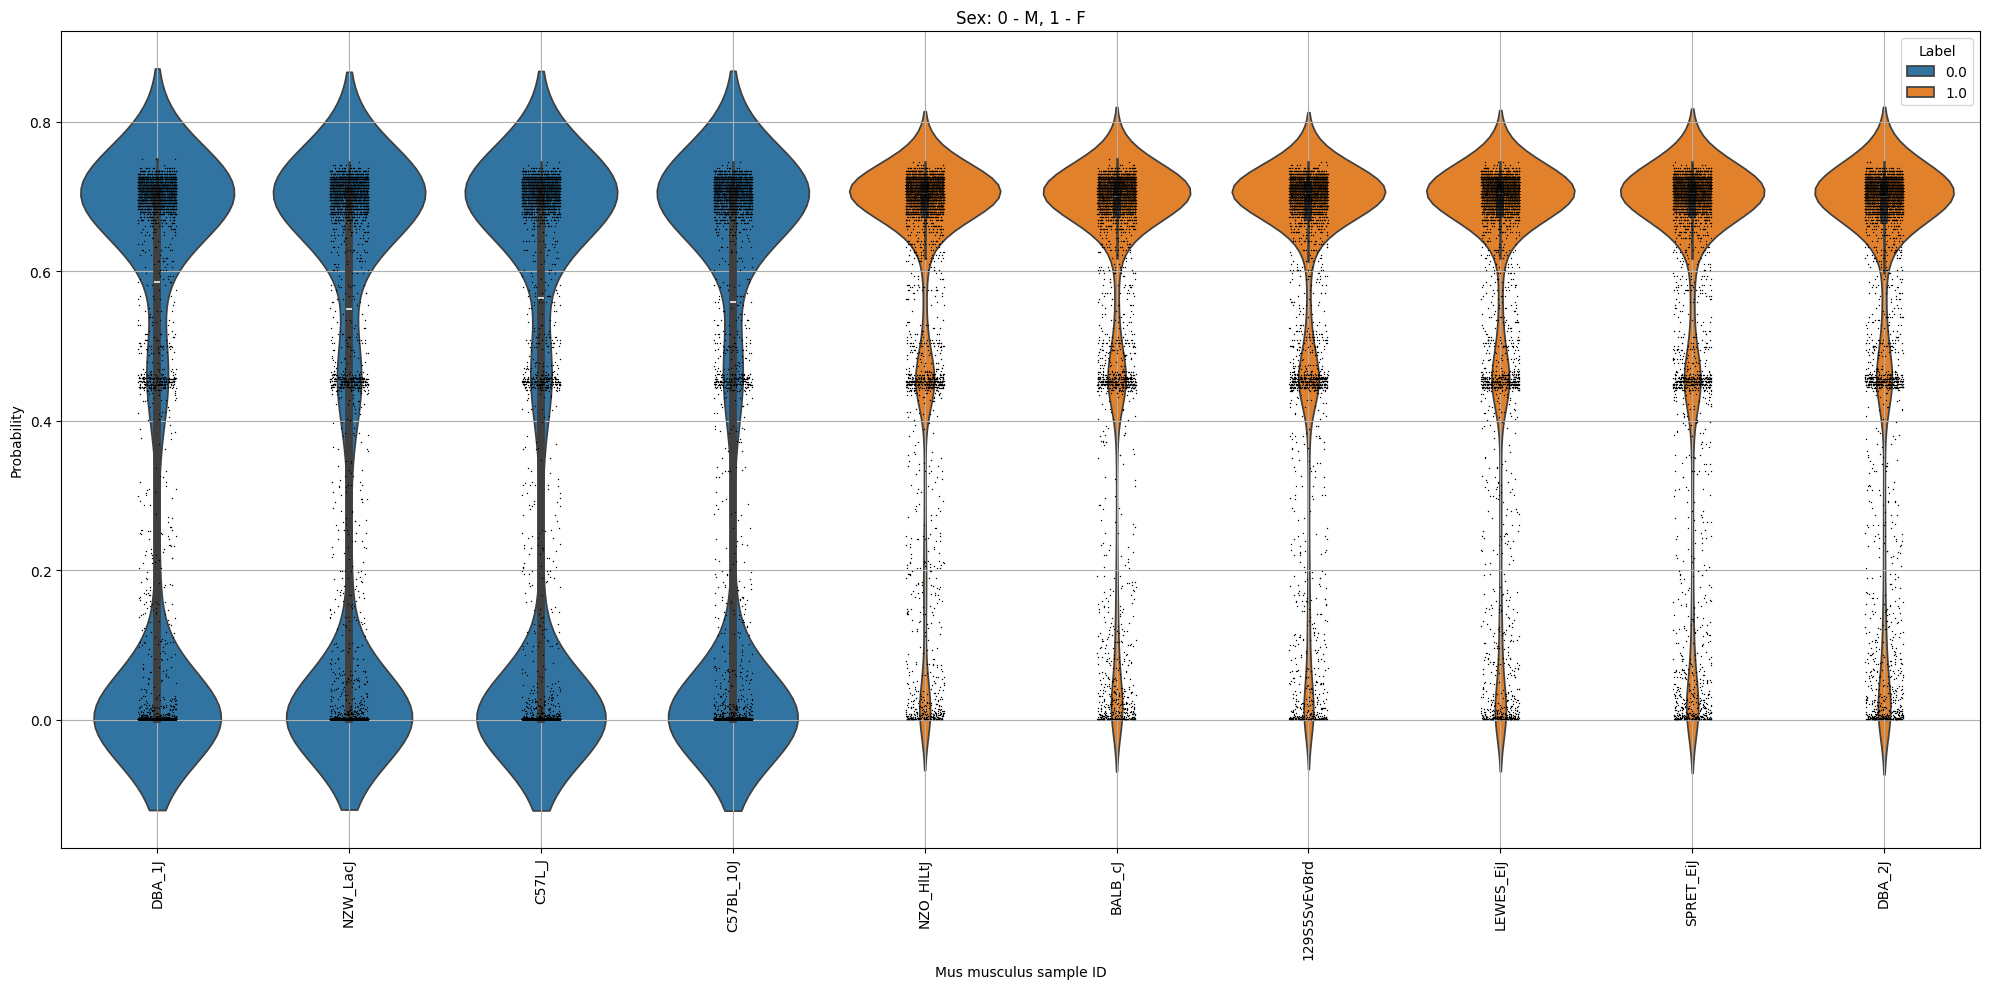

In [23]:
# Prepare DataFrame for plotting
data_list = []
for sample_id, probs in sample_ids_probs.items():
    if sample_id in list(labels_mouse_test['strain_name']) or sample_id in list(labels_mouse_valid['strain_name']):
        for prob in probs:
            data_list.append({
                'Sample ID': sample_id,  # Convert to string for consistent key usage
                'Probability': prob[0],
                'Label': sample_ids_labels[sample_id]
            })

df = pd.DataFrame(data_list)

# Sort data by label for plotting
label_order = sorted(df['Label'].unique())
sample_order = df.sort_values(by='Label')['Sample ID'].unique()

# Plotting
plt.figure(figsize=(20, 10))  # Adjusted size for better visibility
ax = sns.violinplot(x='Sample ID', y='Probability', hue='Label', data=df, inner='box',
                    order=sample_order, hue_order=label_order)
sns.stripplot(x='Sample ID', y='Probability', data=df, color='black', size=1, jitter=True, order=sample_order)
plt.title('Sex: 0 - M, 1 - F')
plt.xticks(rotation=90)
plt.xlabel('Mus musculus sample ID')
plt.ylabel('Probability')
plt.legend(title='Label')
plt.tight_layout()
plt.grid()
plt.show()

In [21]:
probs = [elem['Probability'] for elem in data_list]
assert all([prob > 0 for prob in probs])

accuracy: 0.900, thr: 0.809
C57BL_10J      : [0.0] 2544/4984 = 0.510 pred: [0]         contain Y: True         contain X: True
DBA_1J         : [0.0] 2563/5010 = 0.512 pred: [0]         contain Y: True         contain X: True
C57L_J         : [0.0] 2549/4988 = 0.511 pred: [0]         contain Y: True         contain X: True
NZW_LacJ       : [0.0] 2530/4988 = 0.507 pred: [0]         contain Y: True         contain X: True
BALB_cJ        : [1.0] 4093/5012 = 0.817 pred: [1]         contain Y: False         contain X: True
LEWES_EiJ      : [1.0] 4139/5066 = 0.817 pred: [1]         contain Y: False         contain X: True
129S5SvEvBrd   : [1.0] 4061/4970 = 0.817 pred: [1]         contain Y: False         contain X: True
SPRET_EiJ      : [1.0] 4097/5048 = 0.812 pred: [1]         contain Y: False         contain X: True
DBA_2J         : [1.0] 4165/5162 = 0.807 pred: [0]         contain Y: False         contain X: True
NZO_HlLtJ      : [1.0] 4119/5042 = 0.817 pred: [1]         contain Y: False 

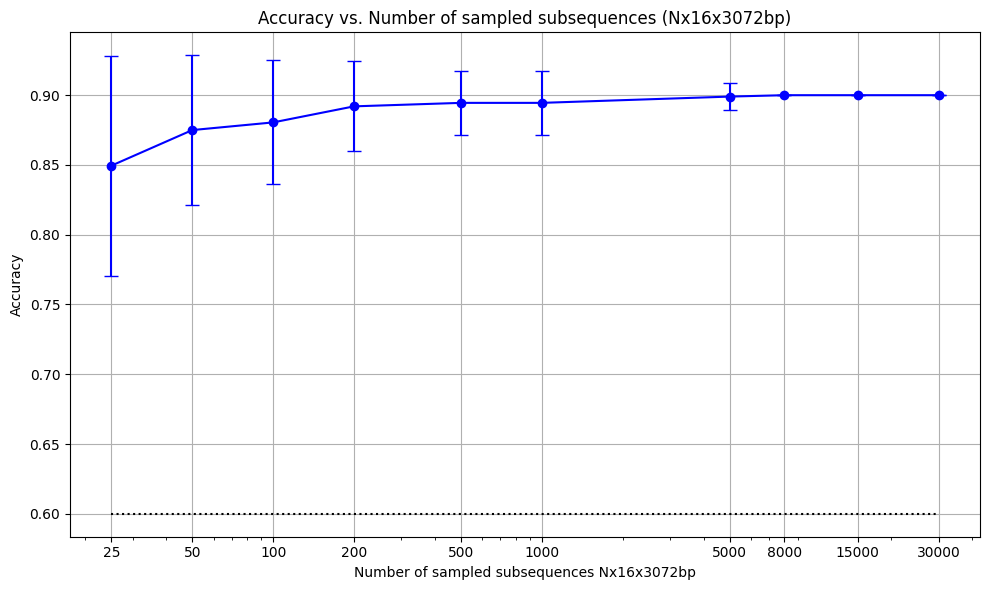

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sample_ids_mouses = {sample_id: label for sample_id, label in sample_ids_labels.items() if sample_id in list(labels_mouse_test['strain_name']) or sample_id in list(labels_mouse_valid['strain_name'])}
sample_ids_sorted = [el[0] for el in sorted(sample_ids_mouses.items(), key=lambda x: x[1])]

thr = 0.5

ratios = []
for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    ratios += [(probs>thr).sum() / len(probs)]

ratios = np.array(ratios)

acc = 0
for k, r in zip(sample_ids_sorted, ratios):
    acc += int(int(r > np.median(ratios)) == sample_ids_mouses[k])
acc = acc / len(sample_ids_sorted)
print(f'accuracy: {acc:0.3f}, thr: {np.median(ratios):0.3f}')


for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    r = (probs>thr).sum()/len(probs)
    print(f"{k:15s}: [{sample_ids_mouses[k]}] {(probs>thr).sum()}/{len(probs)} = {r:.3f} pred: [{int(r>np.median(ratios))}] \
        contain Y: {any(['chrY' in elem for elem in sample_ids_sampled_chromosomes[k]])} \
        contain X: {any(['chrX' in elem for elem in sample_ids_sampled_chromosomes[k]])}")

Ns = [25, 50, 100, 200, 500, 1000, 5000, 8000, 15000, 30000]
# thr = 0.3
accs = []
stds = []
Ns_containX = {}
Ns_containY = {}


for N in Ns:
    N_accs = []
    Ns_containX[N] = []
    Ns_containY[N] = []
    for i in range(200):
        ratios = []
        for k in sample_ids_sorted:
            probs = sample_ids_probs[k]
            prob_idxs = np.random.choice(list(range(len(probs[:,0]))), size=min(N, len(probs)))
            # probs = np.random.choice(probs[:,0],size=min(N, len(probs)))
            probs = probs[:,0][prob_idxs]
            chrs = [sample_ids_sampled_chromosomes[k][idx] for idx in prob_idxs]
            ratios += [(probs>thr).sum() / len(probs)]
            # print(f"{k}: [{sample_ids_labels[k]}] {(probs>thr).sum()}/{len(probs)} = {(probs>thr).sum() / len(probs):.3f} \
                # contain X: {any(['chrX' in elem for elem in chrs])} contain Y: {any(['chrY' in elem for elem in chrs])}")
            
            Ns_containX[N].append(any(['chrX' in elem for elem in chrs]))
            Ns_containY[N].append(any(['chrY' in elem for elem in chrs]))

        ratios = np.array(ratios)

        acc = 0
        for k, r in zip(sample_ids_sorted, ratios):
            acc += int(int(r > np.median(ratios)) == sample_ids_mouses[k])
        acc = acc / len(sample_ids_sorted)
        N_accs += [acc]
    accs += [np.mean(N_accs)]
    stds.append(np.std(N_accs))

for N in Ns:
    print(f"{N} samples, probablity of X: {sum(Ns_containX[N])/len(Ns_containX[N])}")
    print(f"{N} samples, probablity of Y: {sum(Ns_containY[N])/len(Ns_containY[N])}")
# Creating the plot
plt.figure(figsize=(10, 6))
# plt.plot(Ns, accs, marker='o', linestyle='-', color='b')
plt.errorbar(Ns, accs, yerr=stds, marker='o', linestyle='-', color='b', capsize=5)
plt.hlines(np.mean(list(sample_ids_mouses.values())), xmin=min(Ns), xmax=max(Ns), color='black', linestyle='dotted')
plt.title(f'Accuracy vs. Number of sampled subsequences (Nx16x3072bp)')
plt.xlabel('Number of sampled subsequences Nx16x3072bp')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xscale('log')  # Optional: Use logarithmic scale for better visualization if needed
plt.xticks(Ns, labels=[str(n) for n in Ns])  # Ensure that all N values are labeled
plt.tight_layout()
plt.show()

array([0.69921875, 0.6953125 ], dtype=float32)

accuracy: 1.000, thr: 0.221
NA12707        : [0.0] 1060/4990 = 0.212 pred: [0]
HG02947        : [0.0] 1028/4966 = 0.207 pred: [0]
HG02489        : [0.0] 1075/5096 = 0.211 pred: [0]
NA20528        : [0.0] 1023/5062 = 0.202 pred: [0]
HG02554        : [0.0] 1057/5038 = 0.210 pred: [0]
HG04018        : [1.0] 1124/4832 = 0.233 pred: [1]
HG01936        : [1.0] 1192/5160 = 0.231 pred: [1]
HG00405        : [1.0] 1099/4802 = 0.229 pred: [1]
HG01067        : [1.0] 1146/4908 = 0.233 pred: [1]
HG03807        : [1.0] 1133/4844 = 0.234 pred: [1]
25 samples, probablity of X: 0.6215
25 samples, probablity of Y: 0.1035
50 samples, probablity of X: 0.8205
50 samples, probablity of Y: 0.186
100 samples, probablity of X: 0.9655
100 samples, probablity of Y: 0.2995
200 samples, probablity of X: 0.9965
200 samples, probablity of Y: 0.4235
500 samples, probablity of X: 1.0
500 samples, probablity of Y: 0.4945
1000 samples, probablity of X: 1.0
1000 samples, probablity of Y: 0.4995
5000 samples, probablity of

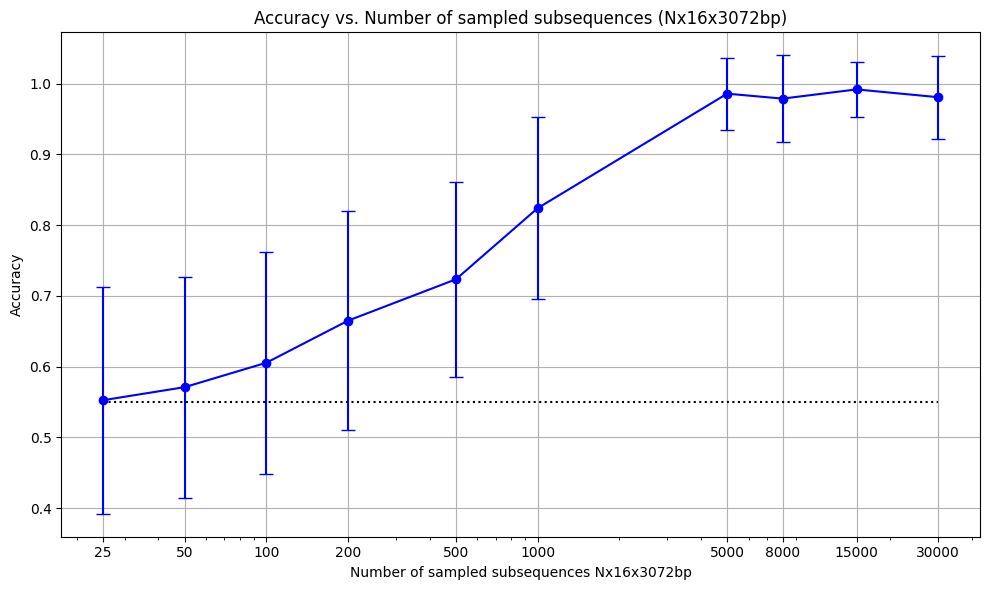

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sample_ids_human = {sample_id: label for sample_id, label in sample_ids_labels.items() if sample_id in list(labels_human_valid['sample']) or sample_id in list(labels_human_test['sample'])}
sample_ids_sorted = [el[0] for el in sorted(sample_ids_human.items(), key=lambda x: x[1])]

thr = 0.5

ratios = []
for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    ratios += [(probs>thr).sum() / len(probs)]

ratios = np.array(ratios)

acc = 0
for k, r in zip(sample_ids_sorted, ratios):
    acc += int(int(r > np.median(ratios)) == sample_ids_human[k])
acc = acc / len(sample_ids_sorted)
print(f'accuracy: {acc:0.3f}, thr: {np.median(ratios):0.3f}')


for k in sample_ids_sorted:
    probs = sample_ids_probs[k]
    r = (probs>thr).sum()/len(probs)
    print(f"{k:15s}: [{sample_ids_human[k]}] {(probs>thr).sum()}/{len(probs)} = {r:.3f} pred: [{int(r>np.median(ratios))}]")

Ns = [25, 50, 100, 200, 500, 1000, 5000, 8000, 15000, 30000]
# thr = 0.3
accs = []
stds = []


for N in Ns:
    N_accs = []
    Ns_containX[N] = []
    Ns_containY[N] = []
    
    for i in range(200):
        ratios = []
        for k in sample_ids_sorted:
            probs = sample_ids_probs[k]
            # probs = np.random.choice(probs[:,0],size=min(N, len(probs)))
            prob_idxs = np.random.choice(list(range(len(probs[:,0]))), size=min(N, len(probs)))
            probs = probs[:,0][prob_idxs]
            chrs = [sample_ids_sampled_chromosomes[k][idx] for idx in prob_idxs]
            ratios += [(probs>thr).sum() / len(probs)]
            # print(f"{k}: [{sample_ids_human[k]}] {(probs>thr).sum()}/{len(probs)} = {(probs>thr).sum() / len(probs):.3f}")
                        
            Ns_containX[N].append(any(['chrX' in elem for elem in chrs]))
            Ns_containY[N].append(any(['chrY' in elem for elem in chrs]))

        ratios = np.array(ratios)

        acc = 0
        for k, r in zip(sample_ids_sorted, ratios):
            acc += int(int(r > np.median(ratios)) == sample_ids_human[k])
        acc = acc / len(sample_ids_sorted)
        N_accs += [acc]
    accs += [np.mean(N_accs)]
    stds.append(np.std(N_accs))

for N in Ns:
    print(f"{N} samples, probablity of X: {sum(Ns_containX[N])/len(Ns_containX[N])}")
    print(f"{N} samples, probablity of Y: {sum(Ns_containY[N])/len(Ns_containY[N])}")

# Creating the plot
plt.figure(figsize=(10, 6))
# plt.plot(Ns, accs, marker='o', linestyle='-', color='b')
plt.errorbar(Ns, accs, yerr=stds, marker='o', linestyle='-', color='b', capsize=5)
plt.hlines(np.mean(list(sample_ids_labels.values())), xmin=min(Ns), xmax=max(Ns), color='black', linestyle='dotted')
plt.title(f'Accuracy vs. Number of sampled subsequences (Nx16x3072bp)')
plt.xlabel('Number of sampled subsequences Nx16x3072bp')
plt.ylabel('Accuracy')
plt.grid(True)
plt.xscale('log')  # Optional: Use logarithmic scale for better visualization if needed
plt.xticks(Ns, labels=[str(n) for n in Ns])  # Ensure that all N values are labeled
plt.tight_layout()
plt.show()